# Exercise 2: PCA

In this exercise, we will be using the same extracted "Bank Marketing" dataset, "bank-200.csv", from the K-Means exercise.

Your task now is to perform a dimension reduction on the provided dataset using the scikit-learn library and then build a model using K-Means. The process should include steps like data exploration, cleaning (if necessary), model building, and etc. 

## Task 1 - Data Exploration
- Load the dataset and perform basic data exploration.
- Clean the dataset if necessary.

In [1]:
# Import the libraries

import os
from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.cluster import KMeans
import seaborn as sns


import warnings
# Ignore FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Ignore UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

# import dataset
df = pd.read_csv('bank-200 - Copy.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        200 non-null    int64 
 1   job        200 non-null    object
 2   marital    200 non-null    object
 3   education  200 non-null    object
 4   default    200 non-null    object
 5   balance    200 non-null    int64 
 6   housing    200 non-null    object
 7   loan       200 non-null    object
 8   contact    200 non-null    object
 9   day        200 non-null    int64 
 10  month      200 non-null    object
 11  duration   200 non-null    int64 
 12  campaign   200 non-null    int64 
 13  pdays      200 non-null    int64 
 14  previous   200 non-null    int64 
 15  poutcome   200 non-null    object
 16  y          200 non-null    object
dtypes: int64(7), object(10)
memory usage: 26.7+ KB


In [2]:
print("     NULL        ")
print(df.isnull().sum())
print("")
print("     DUPLICATES        ")
print(df.duplicated().sum())

     NULL        
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

     DUPLICATES        
0


## Task 2 - Data Visualization
- Perform some basic data visualization on the dataset to gain more insight on the dataset.

In [3]:
numeric_df = df.iloc[:, [0, 5, 9, 11, 12, 13, 14]]
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,57,retired,divorced,secondary,no,39,yes,no,cellular,30,jul,354,3,-1,0,unknown,no
196,27,blue-collar,single,secondary,no,5563,yes,no,unknown,30,may,435,2,-1,0,unknown,no
197,38,services,married,secondary,no,1,no,yes,cellular,21,nov,152,2,-1,0,unknown,no
198,42,technician,married,tertiary,no,782,no,no,cellular,3,apr,285,1,-1,0,unknown,no


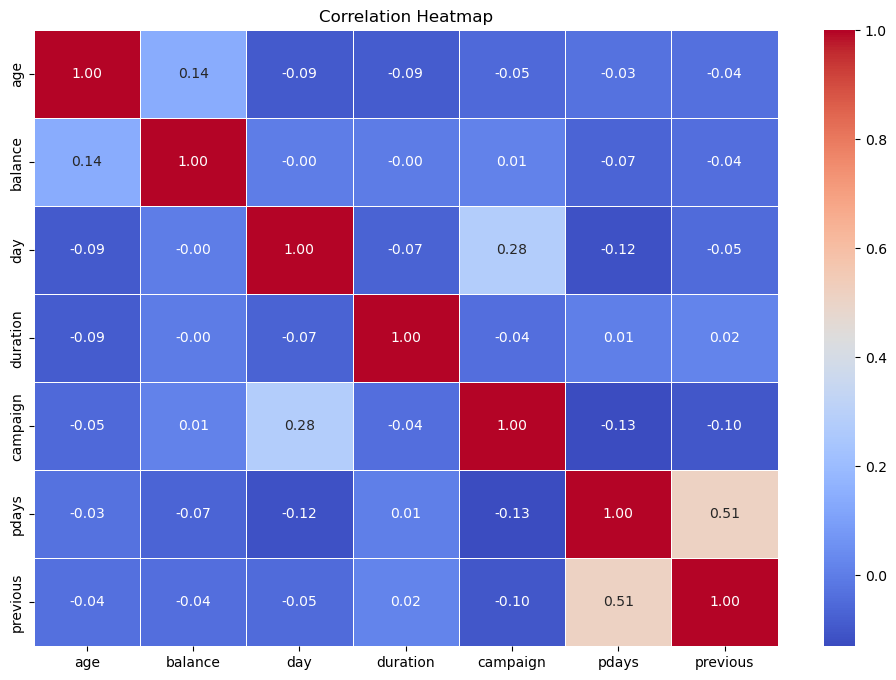

In [4]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

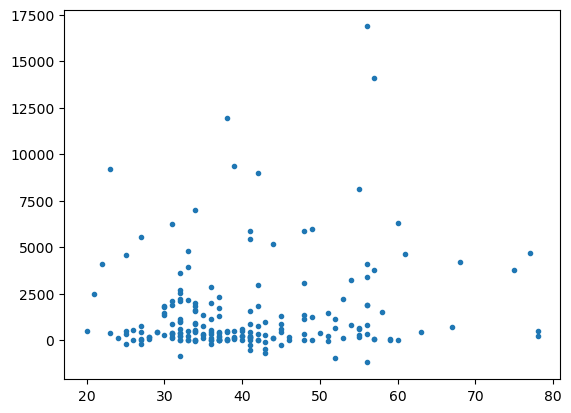

In [5]:
plt.scatter(numeric_df['age'], numeric_df['balance'], marker= '.')

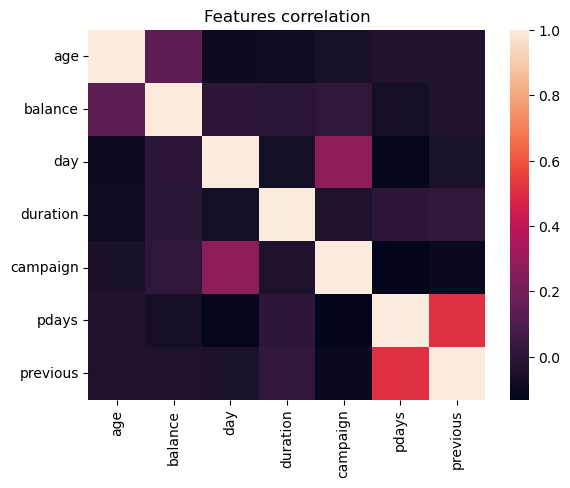

In [6]:
sns.heatmap(numeric_df.corr())
plt.title("Features correlation")
plt.show()

## Task 3 - Scaling and Encoding
- Scale and encode the features if required.

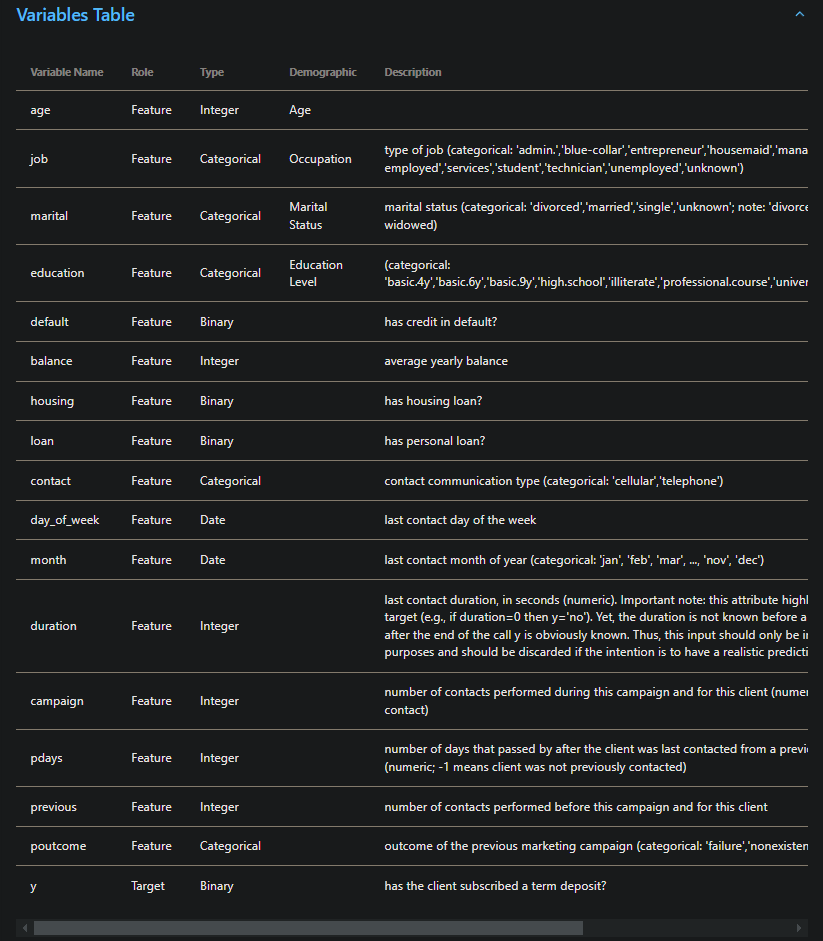

In [7]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features


Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [8]:
numerical_scaled = StandardScaler().fit_transform(df[numerical_features])
df[numerical_features] = numerical_scaled
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,-0.927429,unemployed,married,primary,no,0.145232,no,no,cellular,0.366131,oct,-0.721117,-0.645939,-0.433610,-0.311003,unknown,no
1,-0.659515,services,married,secondary,no,1.350633,yes,yes,cellular,-0.598959,may,-0.145562,-0.645939,2.975510,1.950835,failure,no
2,-0.480906,management,single,tertiary,no,-0.030237,yes,no,cellular,0.004222,apr,-0.288430,-0.645939,2.885269,0.254457,failure,no
3,-0.927429,management,married,tertiary,no,0.020356,yes,yes,unknown,-1.564050,jun,-0.231283,0.910540,-0.433610,-0.311003,unknown,no
4,1.662406,blue-collar,married,secondary,no,-0.572306,yes,no,unknown,-1.322777,may,-0.121071,-0.645939,-0.433610,-0.311003,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.483797,retired,divorced,secondary,no,-0.556646,yes,no,cellular,1.693131,jul,0.401419,0.391714,-0.433610,-0.311003,unknown,no
196,-1.195343,blue-collar,single,secondary,no,1.661419,yes,no,unknown,1.693131,may,0.732056,-0.127112,-0.433610,-0.311003,unknown,no
197,-0.212992,services,married,secondary,no,-0.571905,no,yes,cellular,0.607404,nov,-0.423135,-0.127112,-0.433610,-0.311003,unknown,no
198,0.144227,technician,married,tertiary,no,-0.258308,no,no,cellular,-1.564050,apr,0.119764,-0.645939,-0.433610,-0.311003,unknown,no


In [13]:
binary_cols = ["default", "housing", "loan", "y"]
multi_category_cols = ["job", "marital", "education", "contact", "day", "month", "poutcome"]

multi_category_cols = [col for col in multi_category_cols if col in df.columns]

OHencoder = OneHotEncoder(drop="first", sparse_output=False)
OHencoded_features = OHencoder.fit_transform(df[multi_category_cols])
OHencoded_df = pd.DataFrame(OHencoded_features, columns=OHencoder.get_feature_names_out(multi_category_cols))

df = df.drop(columns=multi_category_cols)
df = pd.concat([df, OHencoded_df], axis=1)

for col in binary_cols:
    lencoder = LabelEncoder()
    df[col] = lencoder.fit_transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 69 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       200 non-null    float64
 1   default                   200 non-null    int64  
 2   balance                   200 non-null    float64
 3   housing                   200 non-null    int64  
 4   loan                      200 non-null    int64  
 5   duration                  200 non-null    float64
 6   campaign                  200 non-null    float64
 7   pdays                     200 non-null    float64
 8   previous                  200 non-null    float64
 9   y                         200 non-null    int64  
 10  job_blue-collar           200 non-null    float64
 11  job_entrepreneur          200 non-null    float64
 12  job_housemaid             200 non-null    float64
 13  job_management            200 non-null    float64
 14  job_retire

## Task 4 - Perform PCA and Model Building
- Reduce the dimensions of the data to 2 and build your K-means model from there.

## Task 5 - Visualize the Plotting
- Plot and visualize the clustering of the data.